# Zadanie obowiązkowe [0-10] pkt

Użyj zbioru danych [Yeast](https://archive.ics.uci.edu/dataset/110/yeast) i powtórz kroki z ćwiczeń.


1. [0-2 pkt] Używając [GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html), dokonaj przeszukania przestrzeni hiperparametrów kNN, zmieniając (uargumentuj wybór zakresów):
   1. liczbę sąsiadów
   1. wagę dla sąsiadów
   1. metrykę
1. [0-1.5 pkt] Do wyszukiwania dodaj miary skuteczności m.in. dokładność (*accuracy*) precyzję (*precision*), czułość (*recall*, *sensitivity*), czy też współczynnik korelacji Matthewsa (MCC). Gdzie to możliwe, dostosuj opcje miar, żeby uwzględniały niezbalansowanie zbioru
1. [0-0.5 pkt] Skomentuj wyniki uzyskane w punktach 1 i 2. Spróbuj zinterpretować wyniki
1. [0-2 pkt] Dokonaj selekcji cech, używając [SequentialFeatureSelector](https://scikit-learn.org/stable/modules/generated/sklearn.feature_selection.SequentialFeatureSelector.html). Zmieniaj parametr `n_features_to_select` od dwóch do pięciu. Ile cech uzyskujemy przy opcji `auto`?
1. [0-0.5 pkt] Używając [Pipeline](https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html), sprawdź wpływ skalowania / normalizacji na wyniki (użyj m.in. `MinMaxScaler` oraz `RobustScaler`)
1. [0-1 pkt] Skomentuj wyniki uzyskane w punktach 4 i 5
1. [0-1.5 pkt] Dla najlepszej pary `n_features_to_select=2` wyryuj obszary decyzyjne. Skomentuj wyniki
1. [0-1 pkt] Czy w świetle uzyskanych wyników, kNN jest odpowiednim klasyfikatorem do tego problemu? Uzasadnij odpowiedź
  
<span style="color:red">**Uwaga:**</span> zadania bez komentarzy i wniosków zostaną ocenione na **0 punktów**.

## Powtórzenie kroków z ćwiczeń

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import sklearn
import numpy as np

from ucimlrepo import fetch_ucirepo 
from sklearn.preprocessing import OrdinalEncoder, LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import f1_score, ConfusionMatrixDisplay

In [2]:
sklearn.set_config(transform_output="pandas")
sklearn.__version__

yeast = fetch_ucirepo(id=110) 
X = yeast.data.features 
y = yeast.data.targets

X[pd.isna(X).any(axis=1)]

idx_to_drop = y[y['localization_site'] == 'ERL'].index
X = X.drop(idx_to_drop)
y = y.drop(idx_to_drop)

label_encoder = LabelEncoder()

y_trans = label_encoder.fit_transform(y['localization_site'].values)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [3]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y_trans, stratify=y_trans,
                                                    test_size=0.1, random_state=0)

knn = KNeighborsClassifier(n_jobs=-1)
knn.fit(X_train, y_train)

y_pred_train = knn.predict(X_train)
y_pred_test  = knn.predict(X_test)

## Grid Search
Szukamy liczbę sąsiadów (default=5), wagę dla sąsiadów (default='uniform', ale możemy ustawić 'distance' lub custom) oraz metrykę (default='minkowski', ale możemy ustawić jeszcze ustawić np. 'cosine', 'cityblock', 'euclidan').

Dla `n_neighbours` wybrałem tylko nieparzyste, bo w przypadku trafienia na granicę 2 klas zmniejsza szansę remisu.

Dla `weights` wybrałem uniform i distance bo to w sumie jedyne możliwe wybory bez pisania funckji samemu.

Dla `metric` wybrałem kilka z prezentacji oraz [dokumentacji](https://scikit-learn.org/stable/modules/generated/sklearn.metrics.pairwise.distance_metrics.html#sklearn.metrics.pairwise.distance_metrics).

In [4]:
from sklearn.model_selection import GridSearchCV

In [5]:
scoring = [
    'accuracy', 
    'precision_macro', # macro oznacza równe traktowanie klas co mocno penalizuje wybieranie tylko klas dominujących
    'recall_macro', # macro analogicznie
    'matthews_corrcoef' # jest zbudowane tak aby automatycznie penalizować ignorowanie mniejszych klas
    ]

param_grid = {
    'n_neighbors': [3, 5, 7, 9, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['euclidean', 'cityblock', 'cosine', 'minkowski', 'l1', 'l2', 'manhattan']
}

knn = KNeighborsClassifier()
grid = GridSearchCV(knn, param_grid, cv=5, scoring=scoring, refit='matthews_corrcoef', n_jobs=-1)
grid.fit(X_train, y_train)

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",KNeighborsClassifier()
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'metric': ['euclidean', 'cityblock', ...], 'n_neighbors': [3, 5, ...], 'weights': ['uniform', 'distance']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.","['accuracy', 'precision_macro', ...]"
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",'matthews_corrcoef'
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : the computation time fo

### Interpretacja wyników
 - `n_neighbours` = 15
 - `weights` = 'distance'
 - `metric` = 'euclidean'

Wysoki wynik liczby sąsiadów sugeruje, że dane są dość zaszumione, a klasy na siebie "nachodzą". Rozpatrywanie większej ilości sąsiadów uodparnia model na takie lokalne anomalie.

Wagi `distance` mają duży sens jeśli weźmiemy pod uwagę fakt, że dla jednomiernej wagi klasy dominujące prawie zawsze by przegłosowały klasy rzadkie dla wyższego `n_neighbours`.

Metryka `euclidean`, czyli standardowa odległość w linii prostej, okazała się najlepsza. Przy 8 cechach nie mamy jeszcze doczynienia z "klątwą wymiarowości", dodatkowo znormalizowaliśmy dane, więc metryka euklidesowa się wydaje odpowiednim wynikiem. Możemy wywnioskować, że skupiska klas mają kształt zbliżony do sferycznego lub eliptycznego, a nie np. jakiejś siatki lub schodków.

## Implementacja SFS

SFS pozwala zredukować wymiarowość przez wybranie najoptymalniejszego podzbioru cech.

In [6]:
from sklearn.feature_selection import SequentialFeatureSelector

best_knn = grid.best_estimator_

for n in range(2, 6):
    sfs = SequentialFeatureSelector(
        estimator=best_knn, 
        n_features_to_select=n, 
        direction='forward', 
        cv=5, 
        n_jobs=-1
    )
    sfs.fit(X_train, y_train)
    
    selected = sfs.get_support(indices=True)
    print(f"n_features_to_select={n} | Wybrane cechy: {X_train.columns[selected].tolist()}")

n_features_to_select=2 | Wybrane cechy: ['alm', 'nuc']
n_features_to_select=3 | Wybrane cechy: ['alm', 'mit', 'nuc']
n_features_to_select=4 | Wybrane cechy: ['mcg', 'alm', 'mit', 'nuc']
n_features_to_select=5 | Wybrane cechy: ['mcg', 'gvh', 'alm', 'mit', 'nuc']


In [7]:
sfs_auto = SequentialFeatureSelector(
    estimator=best_knn, 
    n_features_to_select='auto', 
    direction='forward', 
    cv=5, 
    n_jobs=-1
)
sfs_auto.fit(X_train, y_train)
print(f"'auto': {X_train.columns[sfs_auto.get_support(indices=True)].tolist()}")

'auto': ['mcg', 'alm', 'mit', 'nuc']


### Wnioski
Widzimy, że parametrami o najwyższej mocy wyboru klasy są **'alm'** i **'nuc'**.

`auto` wybrało redukcje z 8 do 4 cech. Odrzucone zmienne wprowadzały szum informacji oraz zaburzały obliczenia metryki euklidowskiej (gdzie każdy parametr jest wart tyle samo).

## Wpływ skalowania i normalizacji na wyniki

In [8]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.model_selection import cross_validate

In [9]:
X_train, X_test, y_train, y_test = train_test_split(X, y_trans, stratify=y_trans,
                                                    test_size=0.1, random_state=0)

# musimy jeszcze raz to zrobić bo wcześniejsze X_train itd były już przeskalowane StandardScalerem
# były w ogóle przeskalowane przed podziałem co powoduje Data Leakage

In [10]:
best_knn = grid.best_estimator_

pipelines = {
    "NoScaler": Pipeline([
        ('knn', best_knn)
    ]),
    "StandardScaler": Pipeline([
        ('scaler', StandardScaler()), 
        ('knn', best_knn)
    ]),
    "MinMaxScaler": Pipeline([
        ('scaler', MinMaxScaler()), 
        ('knn', best_knn)
    ]),
    "RobustScaler": Pipeline([
        ('scaler', RobustScaler()), 
        ('knn', best_knn)
    ])
}

for name, pipeline in pipelines.items():
    cv_results = cross_validate( # używamy cv aby wynik był stabilny i niezależny od losowości podziału danych
        estimator=pipeline, 
        X=X_train, 
        y=y_train, 
        cv=5, 
        scoring=scoring,
        n_jobs=-1
    )
    
    mean_mcc = np.mean(cv_results['test_matthews_corrcoef'])
    print(f"{name} - MCC: {mean_mcc:.4f}")

NoScaler - MCC: 0.4759
StandardScaler - MCC: 0.4982
MinMaxScaler - MCC: 0.4904
RobustScaler - MCC: 0.4784


### Wnioski
Najgorszym wynikiem jest ten bez skalowania. Ze względu na to, że używamy w `best_knn` metryki euklidowskiej (czyli opartej na odległości) to oczywiste jest to, że wysokie różnice wartości wprowadzają większą wagę dla danego parametru, czego nie chcemy, więc standaryzacja jest potrzebna.

Najlepszym wynikiem jest `StandardScaler`, co wskazuje na to, że zachowanie informacji o wariacji danych i ich rozkładzie jest skuteczniejsze (chociaż nie jakoś bardzo) niż sztywne skompresowanie wartości do przedziału [0,1], czyli `MinMaxScaler`.

Ogólnie wyniki są dobre.

## Obszary decyzyjne

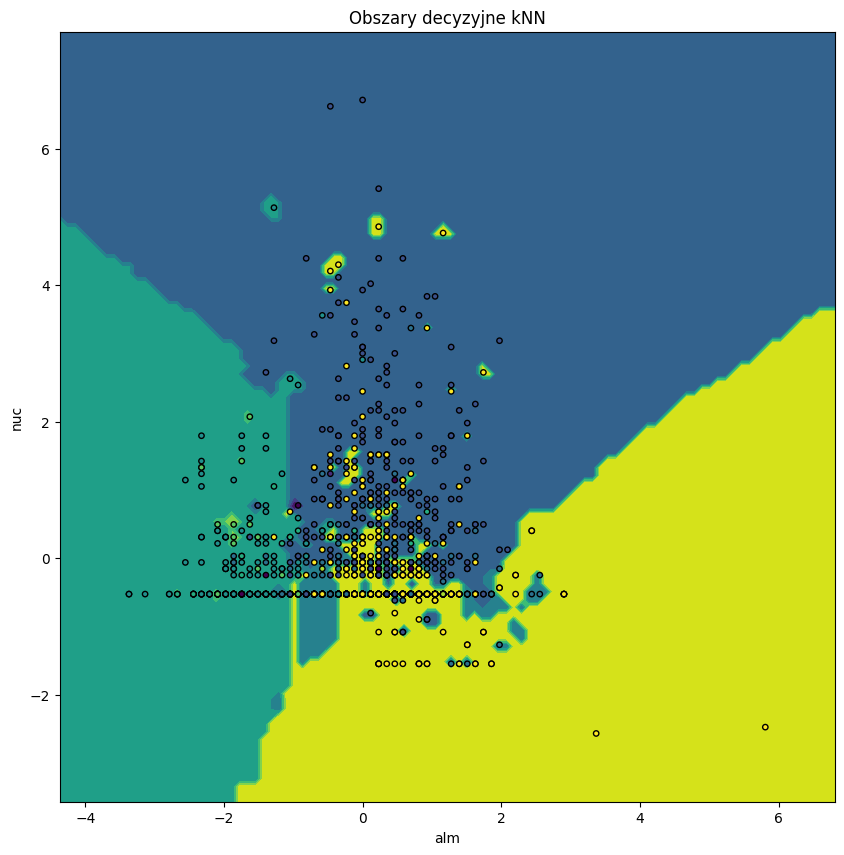

In [11]:
from sklearn.inspection import DecisionBoundaryDisplay

features = ['alm', 'nuc'] # wybrane z podpunktu 4
X_train_2d = X_train[features]

scaler = StandardScaler() # najskuteczniejszy co wiemy z podpunktu 5
X_train_2d = scaler.fit_transform(X_train_2d)

knn_2d = KNeighborsClassifier(**best_knn.get_params()) # tworzymy nowy knn dla struktury 2d
knn_2d.fit(X_train_2d, y_train)

fig, ax = plt.subplots(figsize=(10, 10))

DecisionBoundaryDisplay.from_estimator(
    knn_2d,
    X_train_2d,
    response_method="predict",
    cmap='viridis_r', 
    ax=ax,
    xlabel="alm",
    ylabel="nuc"
)

ax.scatter(
    X_train_2d['alm'], 
    X_train_2d['nuc'], 
    c=y_train, 
    cmap='viridis_r', 
    edgecolors='k',
    s=15
)
plt.title("Obszary decyzyjne kNN")
plt.show()

## Czy kNN jest dobrym klasyfikatorem dla tego problemu?
**Nie.** Klasy silnie na siebie zachodzą, więc model oparty na odległości staje się nieskuteczny - tworzy "enklawy" dla pojedynczych odizolowanych przypadków. Dodatkowo można powiedzieć, że pomimo użycia `weights='distance'` to model strukturalnie "gubi" mniej liczne klasy na rzecz 3 najliczniejszych klas, które monopolizują większość wykresu swoimi obszarami decyzyjnymi.